# Regression model

## Data import

In [ ]:
import numpy as np
import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from numpy.typing import ArrayLike
import tensorflow as tf
from module import time_to_float, time_to_float_old

# Load the small dataset to start training
x_75 = np.load("A1_data_75/images.npy")
y_75 = np.load("A1_data_75/labels.npy")
x_75 = x_75 / 255.0

# Split into training and test set and shuffle and since the datasets are ordered,
# it is recommended in the assignment spec to shuffle
x_75_train, x_75_test, y_75_train, y_75_test = train_test_split(x_75, y_75,
                        test_size = 0.10, random_state = 2029197, shuffle = True)

# Split again into training-validation sets
x_75_train, x_75_validation, y_75_train, y_75_validation = train_test_split(x_75_train, y_75_train,
                        test_size = 0.10, random_state = 202197, shuffle = True)

# Convert y sets into continuous numbers
y_75_train_old = time_to_float_old(y_75_train)
y_75_test_old = time_to_float_old(y_75_test)
y_75_validation_old = time_to_float_old(y_75_validation)
y_75_train = time_to_float(y_75_train)
y_75_test = time_to_float(y_75_test)
y_75_validation = time_to_float(y_75_validation)

# Add channel to train data
x_train_conv = x_75_train.reshape(x_75_train.shape[0], 75, 75, 1)
x_test_conv = x_75_test.reshape(x_75_test.shape[0], 75, 75, 1)
x_validation_conv = x_75_validation.reshape(x_75_validation.shape[0], 75, 75, 1)

# Load the small dataset to start training
x_150 = np.load("A1_data_150/images.npy")
y_150 = np.load("A1_data_150/labels.npy")
x_150 = x_150 / 255.0

# Split into training and test set and shuffle and since the datasets are ordered,
# it is recommended in the assignment spec to shuffle
x_150_train, x_150_test, y_150_train, y_150_test = train_test_split(x_150, y_150,
                        test_size = 0.10, random_state = 2029197, shuffle = True)

# Split again into training-validation sets
x_150_train, x_150_validation, y_150_train, y_150_validation = train_test_split(x_150_train, y_150_train,
                        test_size = 0.10, random_state = 202197, shuffle = True)

# Convert y sets into continuous numbers
y_150_train_old = time_to_float_old(y_150_train)
y_150_test_old = time_to_float_old(y_150_test)
y_150_validation_old = time_to_float_old(y_150_validation)
y_150_train = time_to_float(y_150_train)
y_150_test = time_to_float(y_150_test)
y_150_validation = time_to_float(y_150_validation)

# Add channel to train data
x_train_conv_150 = x_150_train.reshape(x_150_train.shape[0], 150, 150, 1)
x_test_conv_150 = x_150_test.reshape(x_150_test.shape[0], 150, 150, 1)
x_validation_conv_150 = x_150_validation.reshape(x_150_validation.shape[0], 150, 150, 1)

## Model 1

In [ ]:
model = keras.models.Sequential(layers=[
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        kernel_initializer="random_normal",
                        bias_initializer="zeros",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=300,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="sgd",
              loss="mse",
              metrics=[circular_mae_old])
history = model.fit(x_train_conv, y_75_train_old, epochs=30,
                    validation_data=(x_validation_conv, y_75_validation_old))

Epoch 1/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 90s 167ms/step - circular_mae_old: 0.2503 - loss: 0.2049 - val_circular_mae_old: 0.2510 - val_loss: 0.0955
Epoch 2/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 64s 140ms/step - circular_mae_old: 0.2430 - loss: 0.0804 - val_circular_mae_old: 0.2216 - val_loss: 0.0728
Epoch 3/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - circular_mae_old: 0.2101 - loss: 0.0676 - val_circular_mae_old: 0.2207 - val_loss: 0.0954
Epoch 4/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - circular_mae_old: 0.1815 - loss: 0.0554 - val_circular_mae_old: 0.1912 - val_loss: 0.0593
Epoch 5/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - circular_mae_old: 0.1606 - loss: 0.0440 - val_circular_mae_old: 0.1799 - val_loss: 0.0548
Epoch 6/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - circular_mae_old: 0.1410 - loss: 0.0336 - val_circular_mae_old: 0.1788 - val_loss: 0.0565
Epoch 7/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - circular_mae_old: 0.1213 - loss: 0.0243 - val_circular_mae_ol

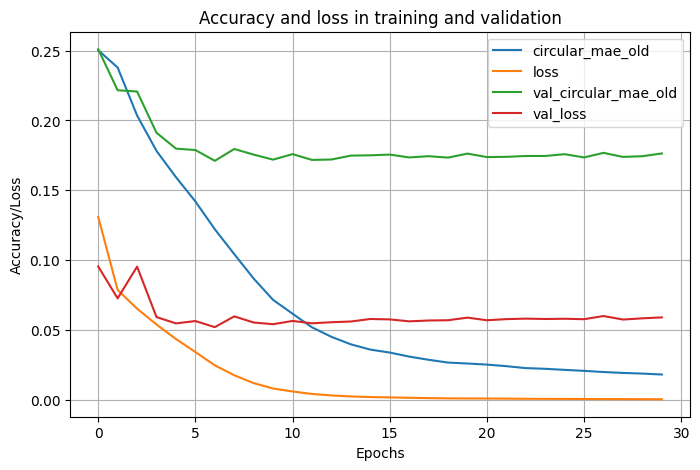

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Accuracy and loss in training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.show()

In [ ]:
results = model.evaluate(x_test_conv, y_75_test_old)
results

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - circular_mae_old: 0.1735 - loss: 0.0587


[0.05760003998875618, 0.17197181284427643]

## Model 2

In [ ]:
model = keras.models.Sequential(layers=[
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        kernel_initializer="random_normal",
                        bias_initializer="zeros",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(filters=300,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=300,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=150,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1, activation="sigmoid")
])
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0002,
    patience=3,
    start_from_epoch=30
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_circular_mae_old', factor=0.8,
                              patience=5, min_lr=0.00001)
optimiser = keras.optimizers.Adam(learning_rate = 0.0001)
model.compile(optimizer=optimiser,
              loss="huber",
              metrics=[circular_mae_old])
history = model.fit(x_train_conv, y_75_train_old, epochs=30,
                    validation_data=(x_validation_conv, y_75_validation_old),
                    callbacks = [early_stop, reduce_lr])

Epoch 1/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 85s 142ms/step - circular_mae_old: 0.2468 - loss: 0.0526 - val_circular_mae_old: 0.2417 - val_loss: 0.0500 - learning_rate: 1.0000e-04
Epoch 2/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 55s 120ms/step - circular_mae_old: 0.2353 - loss: 0.0414 - val_circular_mae_old: 0.1962 - val_loss: 0.0310 - learning_rate: 1.0000e-04
Epoch 3/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - circular_mae_old: 0.2008 - loss: 0.0335 - val_circular_mae_old: 0.1780 - val_loss: 0.0267 - learning_rate: 1.0000e-04
Epoch 4/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - circular_mae_old: 0.1796 - loss: 0.0282 - val_circular_mae_old: 0.1600 - val_loss: 0.0231 - learning_rate: 1.0000e-04
Epoch 5/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - circular_mae_old: 0.1618 - loss: 0.0238 - val_circular_mae_old: 0.1485 - val_loss: 0.0220 - learning_rate: 1.0000e-04
Epoch 6/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 54s 119ms/step - circular_mae_old: 0.1399 - loss: 0.0183 - val_circular_mae_old: 0.12

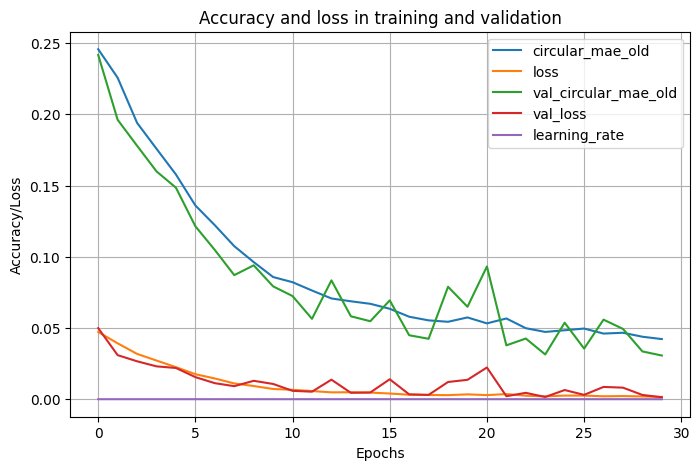

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5), label = ["Train Circular MAE", "Train Loss", "Validation Circular MAE", "Validation Loss"])
plt.grid(True)
plt.title("Accuracy and loss in training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.show()

In [ ]:
results = model.evaluate(x_test_conv, y_75_test_old)
results

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - circular_mae_old: 0.0305 - loss: 0.0016


[0.0016988907009363174, 0.030802719295024872]

In [ ]:
model = keras.models.Sequential(layers=[
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        kernel_initializer="random_normal",
                        bias_initializer="zeros",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(filters=300,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=300,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=150,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1, activation="sigmoid")
])
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0002,
    patience=3,
    start_from_epoch=30
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_circular_mae_old', factor=0.8,
                              patience=5, min_lr=0.00001)
optimiser = keras.optimizers.Adam(learning_rate = 0.0001)
model.compile(optimizer=optimiser,
              loss="huber",
              metrics=[circular_mae_old])
history = model.fit(x_train_conv_150, y_150_train_old, epochs=30,
                    validation_data=(x_validation_conv_150, y_150_validation_old),
                    callbacks = [early_stop, reduce_lr])

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5), label = ["Train Circular MAE", "Train Loss", "Validation Circular MAE", "Validation Loss"])
plt.grid(True)
plt.title("Accuracy and loss in training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.show()

In [ ]:
results = model.evaluate(x_test_conv_150, y_150_test_old)
results

## Model 3

In [ ]:
model = keras.models.Sequential(layers=[
    keras.layers.Conv2D(filters=75,
                        kernel_size=(3,3),
                        padding="same",
                        kernel_initializer="random_normal",
                        bias_initializer="zeros",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(3,3),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(3,3),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(3,3),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=35,
                        kernel_size=(3,3),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=35,
                        kernel_size=(3,3),
                        padding="same",
                        activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(units=150,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=35,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1, activation="linear")
])
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0002,
    patience=3,
    start_from_epoch=10
)
optimiser = keras.optimizers.Adam(learning_rate = 0.0001)
model.compile(optimizer=optimiser,
              loss="huber",
              metrics=[circular_mae])
history = model.fit(x_train_conv, y_75_train, epochs=30,
                    validation_data=(x_validation_conv, y_75_validation),
                    callbacks = [early_stop])

Epoch 1/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - circular_mae: 2.8808 - loss: 2.6942 - val_circular_mae: 2.9315 - val_loss: 3.9269
Epoch 2/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - circular_mae: 2.4365 - loss: 2.1042 - val_circular_mae: 2.4679 - val_loss: 2.1768
Epoch 3/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - circular_mae: 2.2235 - loss: 1.8827 - val_circular_mae: 2.0122 - val_loss: 1.5992
Epoch 4/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - circular_mae: 2.0764 - loss: 1.7178 - val_circular_mae: 1.9285 - val_loss: 1.5516
Epoch 5/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - circular_mae: 1.8486 - loss: 1.4874 - val_circular_mae: 1.8105 - val_loss: 1.5559
Epoch 6/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - circular_mae: 1.6789 - loss: 1.3067 - val_circular_mae: 1.7026 - val_loss: 1.2855
Epoch 7/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - circular_mae: 1.5423 - loss: 1.1590 - val_circular_mae: 1.7323 - val_loss: 1.3323
Epoch 8/30
456/456 ━━━━━━━━━━━━━━━

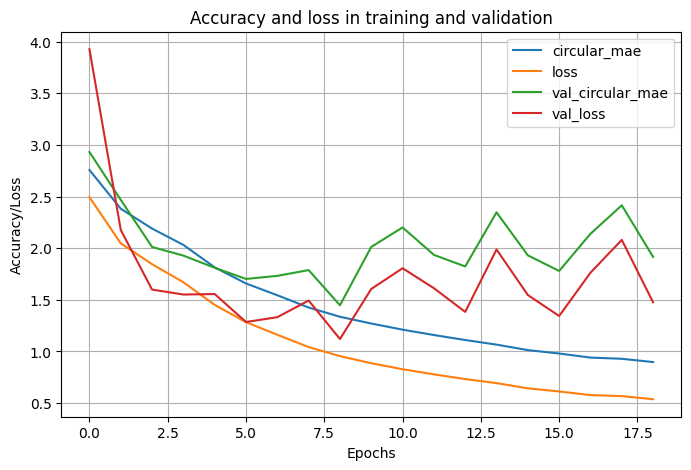

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Accuracy and loss in training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.show()

In [ ]:
results = model.evaluate(x_test_conv, y_75_test)
results

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - circular_mae: 2.0048 - loss: 1.5719


[1.5560506582260132, 1.9963256120681763]

## Model 4

In [ ]:
model = keras.models.Sequential(layers=[
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        kernel_initializer="random_normal",
                        bias_initializer="zeros",
                        activation="relu",
                         kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=35,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=35,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(units=150,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=35,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1, activation="linear")
])
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0002,
    patience=5,
    start_from_epoch=20
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_circular_mae', factor=0.8,
                              patience=5, min_lr=0.00001)
optimiser = keras.optimizers.Adam(learning_rate = 0.0001)
model.compile(optimizer=optimiser,
              loss="huber",
              metrics=[circular_mae])
history = model.fit(x_train_conv, y_75_train, epochs=30,
                    validation_data=(x_validation_conv, y_75_validation),
                    callbacks = [early_stop, reduce_lr])

Epoch 1/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - circular_mae: 2.9932 - loss: 2.8992 - val_circular_mae: 3.0579 - val_loss: 2.7742 - learning_rate: 1.0000e-04
Epoch 2/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - circular_mae: 2.6748 - loss: 2.3226 - val_circular_mae: 2.2165 - val_loss: 1.9485 - learning_rate: 1.0000e-04
Epoch 3/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - circular_mae: 2.1680 - loss: 1.8570 - val_circular_mae: 1.8903 - val_loss: 1.7546 - learning_rate: 1.0000e-04
Epoch 4/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - circular_mae: 1.7336 - loss: 1.4346 - val_circular_mae: 1.5924 - val_loss: 1.3783 - learning_rate: 1.0000e-04
Epoch 5/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - circular_mae: 1.4068 - loss: 1.0994 - val_circular_mae: 1.4249 - val_loss: 1.2005 - learning_rate: 1.0000e-04
Epoch 6/30
456/456 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - circular_mae: 1.1752 - loss: 0.8585 - val_circular_mae: 0.9247 - val_loss: 0.6454 - learning_rate: 1.0000e-04
Epoc

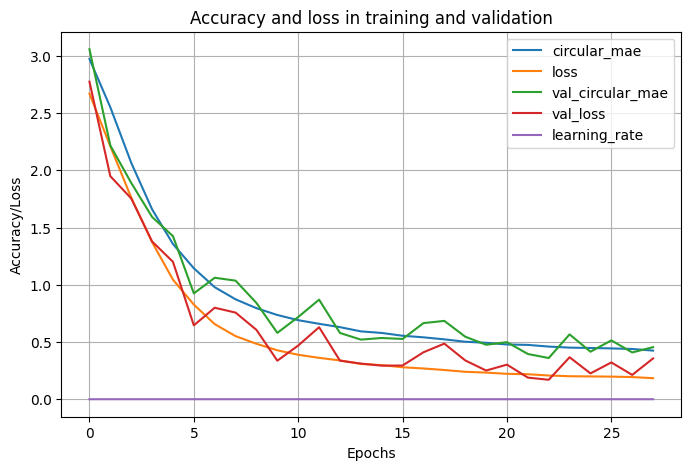

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Accuracy and loss in training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.show()

In [ ]:
results = model.evaluate(x_test_conv, y_75_test)
results

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - circular_mae: 0.4719 - loss: 0.3637


[0.34726423025131226, 0.46826571226119995]

In [ ]:
model = keras.models.Sequential(layers=[
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        kernel_initializer="random_normal",
                        bias_initializer="zeros",
                        activation="relu",
                         kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=75,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=150,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(filters=35,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=35,
                        kernel_size=(2,2),
                        padding="same",
                        activation="relu",
                        kernel_regularizer=keras.regularizers.L2(0.0001)),
    keras.layers.BatchNormalization(),
    keras.layers.Flatten(),
    keras.layers.Dense(units=150,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=75,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=35,
                       activation="relu"),
    keras.layers.LayerNormalization(),
    keras.layers.Dense(1, activation="linear")
])
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0002,
    patience=5,
    start_from_epoch=20
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_circular_mae', factor=0.8,
                              patience=5, min_lr=0.00001)
optimiser = keras.optimizers.Adam(learning_rate = 0.0001)
model.compile(optimizer=optimiser,
              loss="huber",
              metrics=[circular_mae])
history = model.fit(x_train_conv_150, y_150_train, epochs=30,
                    validation_data=(x_validation_conv_150, y_150_validation),
                    callbacks = [early_stop, reduce_lr])

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Accuracy and loss in training and validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Loss")
plt.show()

In [ ]:
results = model.evaluate(x_test_conv_150, y_150_test)
results